In [44]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/transport_data.csv")

df.head()


,livraison_id,date_commande,entrepot,transporteur,distance_km,proba_a_l_heure,a_l_heure,date_livraison_prevue,retard_jours_(nombre),date_livraison_reelle,cout_km_(€),cout_transport_(€)
0,1,2025-05-10,Entrepot_C,Transporteur_Z,450,0.86,True,2025-05-12,0,2025-05-12,1.05,472.0
1,2,2025-02-05,Entrepot_B,Transporteur_Z,564,0.86,True,2025-02-08,0,2025-02-08,1.05,592.0
2,3,2025-07-05,Entrepot_B,Transporteur_Y,615,0.92,True,2025-07-08,0,2025-07-08,1.20,738.0
3,4,2025-06-18,Entrepot_A,Transporteur_X,391,0.77,True,2025-06-20,0,2025-06-20,1.40,547.0
4,5,2025-07-21,Entrepot_A,Transporteur_X,643,0.77,True,2025-07-24,0,2025-07-24,1.40,900.0


In [45]:
df["a_l_heure"].mean()*100

# Calcule taux de service moyen (en %)


np.float64(84.92)

In [46]:
df.groupby("transporteur")["a_l_heure"].mean()*100

# On groupe les transporteurs et on renvoie le taux de service moyen pour chacun (en %).



transporteur
Transporteur_X    77.572873
Transporteur_Y    91.169451
Transporteur_Z    86.062082
Name: a_l_heure, dtype: float64

In [47]:
df.groupby("entrepot")["a_l_heure"].mean()*100

# De même pour les entrepôts (en %).

entrepot
Entrepot_A    85.211268
Entrepot_B    84.839109
Entrepot_C    84.702381
Name: a_l_heure, dtype: float64

In [48]:
df["retard_jours_(nombre)"].mean()

# Calcule la moyenne du retard, (en jour)

np.float64(0.3172)

In [49]:
df.groupby("transporteur")["retard_jours_(nombre)"].mean()

# On calcule la même chose, mais par transporteur (en jour)

transporteur
Transporteur_X    0.478882
Transporteur_Y    0.181384
Transporteur_Z    0.290323
Name: retard_jours_(nombre), dtype: float64

In [50]:
df["cout_transport_(€)"].mean()

# Puis enfin le coût de transport moyen (en €)

np.float64(524.766)

In [51]:
df.groupby("transporteur")["cout_transport_(€)"].mean()

# Le détail de ce coût de transport moyen, mais par transporteur (en €)

transporteur
Transporteur_X    603.041047
Transporteur_Y    523.332339
Transporteur_Z    446.143031
Name: cout_transport_(€), dtype: float64

In [52]:
df["cout_transport_(€)"].sum()/df["distance_km"].sum()

# Cout moyen (en €) observé par kilomètre. 

np.float64(1.218647631494979)

In [53]:
df.groupby("transporteur")["cout_transport_(€)"].sum()

# Quel est le transporteur qui nous coûte le plus cher ? C'est le transporteur X, avec 1.013.712 (€) de frais de transport. Il serait peut-être judicieux d'étudier son cas.

transporteur
Transporteur_X    1013712.0
Transporteur_Y     877105.0
Transporteur_Z     733013.0
Name: cout_transport_(€), dtype: float64

In [54]:
# 1) Tableau par transporteur
tableau = df.groupby("transporteur").agg(
    nb_livraisons=("livraison_id", "count"),
    km_total=("distance_km", "sum"),
    cout_total=("cout_transport_(€)", "sum"),
    cout_moyen=("cout_transport_(€)", "mean"),
    taux_a_l_heure=("a_l_heure", "mean"),
    retard_moyen=("retard_jours_(nombre)", "mean"),
    retard_total=("retard_jours_(nombre)", "sum"),
)

# 2) Totaux globaux (pour calculer les parts)
total_km = tableau["km_total"].sum()
total_cout = tableau["cout_total"].sum()
total_livraisons = tableau["nb_livraisons"].sum()

# 3) Parts (%)
tableau["part_km_%"] = tableau["km_total"] / total_km * 100
tableau["part_cout_%"] = tableau["cout_total"] / total_cout * 100
tableau["part_livraisons_%"] = tableau["nb_livraisons"] / total_livraisons * 100

# 4) Ligne TOTAL 
total = pd.DataFrame({
    "nb_livraisons": [df["livraison_id"].count()],
    "km_total": [df["distance_km"].sum()],
    "cout_total": [df["cout_transport_(€)"].sum()],
    "cout_moyen": [df["cout_transport_(€)"].mean()],
    "taux_a_l_heure": [df["a_l_heure"].mean()],
    "retard_moyen": [df["retard_jours_(nombre)"].mean()],
    "retard_total": [df["retard_jours_(nombre)"].sum()],
    "part_km_%": [100.0],
    "part_cout_%": [100.0],
    "part_livraisons_%": [100.0],
}, index=["TOTAL"])

# 5) Assemblage + arrondi
tableau_final = pd.concat([tableau, total]).round(2)

tableau_final

# Pour se rendre compte de l'importance de chaque transporteur dans notre activité mais aussi pour évaluer individuellement leur performance, autant calculer sommes et moyennes de plusieurs indicateurs clés. 
# On construit un Dataframe brut, et un Dataframe pour calculer moyenne et somme.

,nb_livraisons,km_total,cout_total,cout_moyen,taux_a_l_heure,retard_moyen,retard_total,part_km_%,part_cout_%,part_livraisons_%
Transporteur_X,1681,724066,1013712.0,603.04,0.78,0.48,805,33.63,38.63,33.62
Transporteur_Y,1676,730903,877105.0,523.33,0.91,0.18,304,33.95,33.43,33.52
Transporteur_Z,1643,698098,733013.0,446.14,0.86,0.29,477,32.42,27.94,32.86
TOTAL,5000,2153067,2623830.0,524.77,0.85,0.32,1586,100.00,100.00,100.00


In [55]:
# Première Analyse transporteurs ->
#
# Les comparaisons par transporteur mettent en évidence des écarts nets de performance et de coût :
#
# Transporteur X :
# - Coût moyen et coût total supérieurs aux autres transporteurs.
# - Contribue de manière disproportionnée au cumul des jours de retard.
# => Transporteur à challenger en priorité (revue contractuelle/SLA, allocation de volume, plan d’actions).
#
# Transporteur Y :
# - Meilleur taux de service (livraisons à l’heure) et retard moyen le plus faible.
# - Coût intermédiaire (rapport performance/coût favorable).
# => Transporteur à privilégier pour sécuriser le taux de service.
#
# Transporteur Z :
# - Coût le plus faible.
# - Niveau de retard significatif (part élevée du retard total).
# => Option “économique” à réserver à certains segments (distances, clients moins sensibles, périodes moins critiques).

# Synthèse décideurs : Y pour la qualité, Z pour le coût, X à corriger ou réduire.


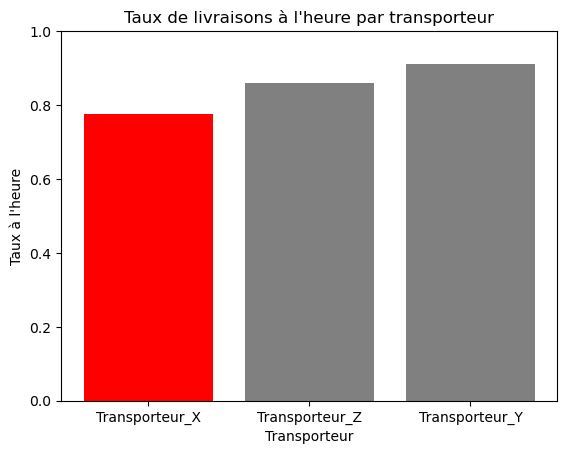

In [56]:
import matplotlib.pyplot as plt

taux = df.groupby("transporteur")["a_l_heure"].mean().sort_values()

colors =["red" if t == "Transporteur_X" else "grey" for t in taux.index]

plt.figure()
plt.bar(taux.index, taux.values, color=colors)
plt.title("Taux de livraisons à l'heure par transporteur")
plt.ylabel("Taux à l'heure")
plt.xlabel("Transporteur")
plt.ylim(0, 1)
plt.show()


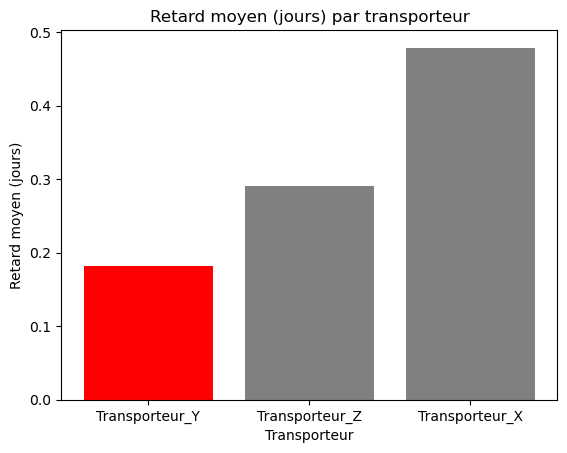

In [57]:
retard = df.groupby("transporteur")["retard_jours_(nombre)"].mean().sort_values()

colors =["red" if t == "Transporteur_X" else "grey" for t in taux.index]

plt.figure()
plt.bar(retard.index, retard.values,color=colors)
plt.title("Retard moyen (jours) par transporteur")
plt.ylabel("Retard moyen (jours)")
plt.xlabel("Transporteur")
plt.show()


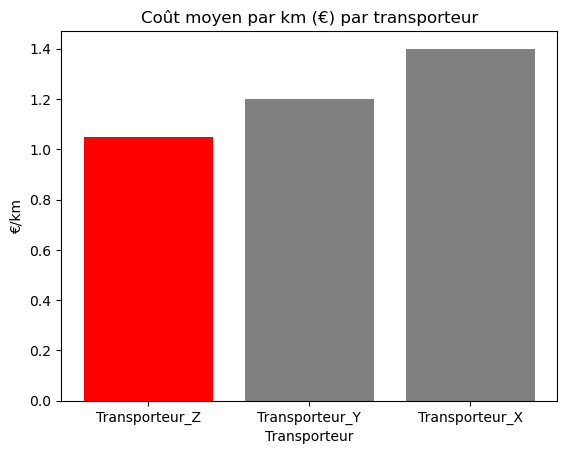

In [58]:
cout_par_km = (
    df.groupby("transporteur")["cout_transport_(€)"].sum()
    / df.groupby("transporteur")["distance_km"].sum()
).sort_values()

colors =["red" if t == "Transporteur_X" else "grey" for t in taux.index]

plt.figure()
plt.bar(cout_par_km.index, cout_par_km.values,color=colors)
plt.title("Coût moyen par km (€) par transporteur")
plt.ylabel("€/km")
plt.xlabel("Transporteur")
plt.show()

# Le coût par kilomètres est à mon sens plus pertinent que coût total.


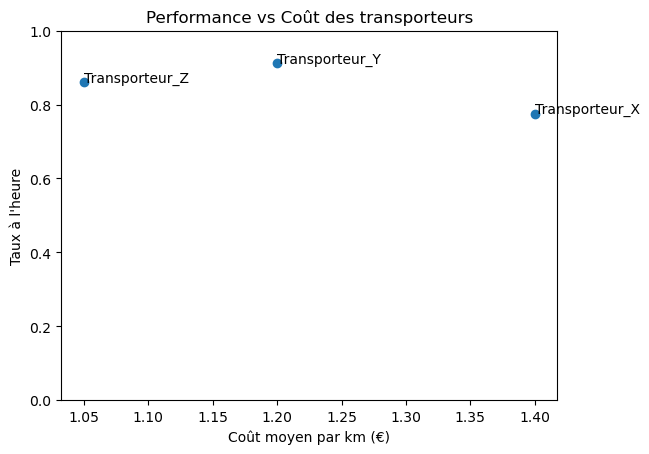

In [59]:
import matplotlib.pyplot as plt

# Calcul coût par km
cout_par_km = (
    df.groupby("transporteur")["cout_transport_(€)"].sum()
    / df.groupby("transporteur")["distance_km"].sum()
)

# Taux à l'heure
taux = df.groupby("transporteur")["a_l_heure"].mean()

plt.figure()

plt.scatter(cout_par_km, taux)

# Ajouter les labels
for transporteur in cout_par_km.index:
    plt.text(
        cout_par_km[transporteur],
        taux[transporteur],
        transporteur
    )

plt.xlabel("Coût moyen par km (€)")
plt.ylabel("Taux à l'heure")
plt.title("Performance vs Coût des transporteurs")

plt.ylim(0, 1)
plt.show()


In [60]:
# Analyse complémentaire – Arbitrage coût / performance
#
# La représentation graphique (coût par km vs taux à l’heure) nuance légèrement
# l’analyse initiale (isssue de l'analyse du Df).
#
# Le transporteur Z apparaît comme le meilleur compromis global :
# - Positionné en haut à gauche du graphique (coût faible / performance élevée),
# - Taux à l’heure compétitif,
# - Coût par km structurellement inférieur aux autres.
#
# Le transporteur Y reste le plus fiable,
# mais son avantage de performance par rapport à Z est relativement limité si l'on considère son coût
# 
#
# En revanche, le transporteur X cumule un positionnement défavorable :
# coût élevé et performance inférieure, ce qui justifie une revue stratégique.
#
# Conclusion décideurs ajustée :
# - Z = transporteur principal (volume cœur)
# - Y = sécurisation des flux stratégiques
# - X = plan d’amélioration ou réduction progressive du volume ? 

# Intéressons-nous maintenant aux entrepots.


In [61]:
# 1) Tableau par entrepôt
tableau_entrepots = df.groupby("entrepot").agg(
    nb_livraisons=("livraison_id", "count"),
    km_total=("distance_km", "sum"),
    cout_total=("cout_transport_(€)", "sum"),
    cout_moyen=("cout_transport_(€)", "mean"),
    taux_a_l_heure=("a_l_heure", "mean"),
    retard_moyen=("retard_jours_(nombre)", "mean"),
    retard_total=("retard_jours_(nombre)", "sum"),
)

# 2) Totaux globaux
total_km = tableau_entrepots["km_total"].sum()
total_cout = tableau_entrepots["cout_total"].sum()
total_livraisons = tableau_entrepots["nb_livraisons"].sum()
total_retard = tableau_entrepots["retard_total"].sum()

# 3) Parts (%)
tableau_entrepots["part_km_%"] = tableau_entrepots["km_total"] / total_km * 100
tableau_entrepots["part_cout_%"] = tableau_entrepots["cout_total"] / total_cout * 100
tableau_entrepots["part_livraisons_%"] = tableau_entrepots["nb_livraisons"] / total_livraisons * 100
tableau_entrepots["part_retard_%"] = tableau_entrepots["retard_total"] / total_retard * 100

# 4) Ligne TOTAL 
total = pd.DataFrame({
    "nb_livraisons": [df["livraison_id"].count()],
    "km_total": [df["distance_km"].sum()],
    "cout_total": [df["cout_transport_(€)"].sum()],
    "cout_moyen": [df["cout_transport_(€)"].mean()],
    "taux_a_l_heure": [df["a_l_heure"].mean()],
    "retard_moyen": [df["retard_jours_(nombre)"].mean()],
    "retard_total": [df["retard_jours_(nombre)"].sum()],
    "part_km_%": [100.0],
    "part_cout_%": [100.0],
    "part_livraisons_%": [100.0],
    "part_retard_%": [100.0],
}, index=["TOTAL"])

# 5) Assemblage finale et arrondi
tableau_entrepots_final = pd.concat([tableau_entrepots, total]).round(3)

tableau_entrepots_final



,nb_livraisons,km_total,cout_total,cout_moyen,taux_a_l_heure,retard_moyen,retard_total,part_km_%,part_cout_%,part_livraisons_%,part_retard_%
Entrepot_A,1704,738639,902953.0,529.902,0.852,0.320,545,34.306,34.414,34.08,34.363
Entrepot_B,1616,678180,822772.0,509.141,0.848,0.314,508,31.498,31.358,32.32,32.030
Entrepot_C,1680,736248,898105.0,534.586,0.847,0.317,533,34.195,34.229,33.60,33.607
TOTAL,5000,2153067,2623830.0,524.766,0.849,0.317,1586,100.000,100.000,100.00,100.000


In [62]:
tableau_entrepots["taux_a_l_heure"].max() - tableau_entrepots["taux_a_l_heure"].min()

# Analyse entrepôts
#
# L’analyse par entrepôt ne révèle pas d’écarts structurels aussi marqués que ceux observés entre transporteurs.
#
# Les niveaux de taux de service, de retard moyen et de coût apparaissent relativement homogènes entre les trois sites.
#
# Aucun entrepôt ne surcontribue significativement au retard total
# au regard de sa part de livraisons ou de kilomètres traités.

# Si l'on s'intéresse à l'écart entre le meilleur taux de livraisons à l'heure et le pire, on constate une différence de 0.5% -> Bruit statistique
#
# Synthèse décideurs :

# Les écarts de performance observés semblent davantage liés au choix du transporteur qu’à un dysfonctionnement structurel
# d’un entrepôt spécifique.



0.005088866532528491

In [ ]:
df["date_commande"] = pd.to_datetime(df["date_commande"])

df["mois"] = df["date_commande"].dt.to_period("M")

df["total_livraisons"]= df

# On reprend notre DataFrame initial et on lui indique que la colonne des dates de commandes peut-être utilisée comme index.
# On ajoute une colonne "mois" en lui demandant de ressortir le mois en fonction de la date de la commande. 


In [ ]:
taux_mensuel = df.groupby("mois")["a_l_heure"].mean()
livraisons_par_mois= df.groupby("mois")["livraison_id"].count()

# Pour chacun des mois on souhaite la moyenne du taux de service, mais aussi le nombre de livraisons total



mois
2025-01    407
2025-02    391
2025-03    459
2025-04    400
2025-05    441
2025-06    389
2025-07    436
2025-08    427
2025-09    408
2025-10    428
2025-11    421
2025-12    393
Freq: M, Name: livraison_id, dtype: int64

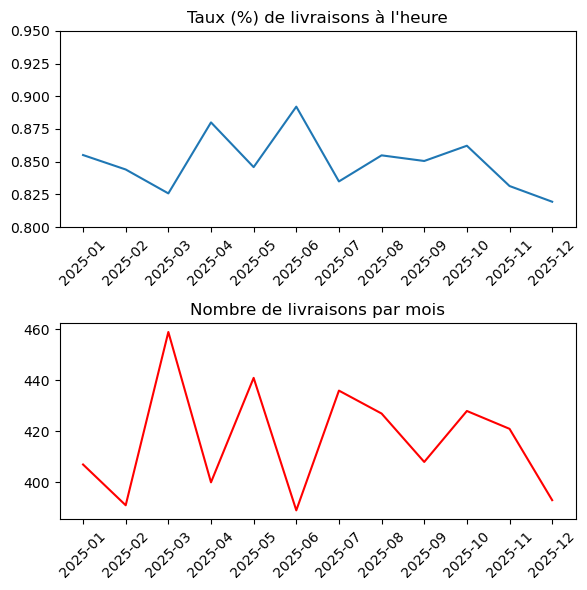

In [108]:
# Construction des deux graphiques reprenant le taux de service par mois + le nombre de livraisons par mois

fig, axes = plt.subplots(2, 1, figsize=(6,6))

# Graphique 1 : taux
axes[0].plot(taux_mensuel.index.astype(str), taux_mensuel.values)
axes[0].set_title("Taux (%) de livraisons à l'heure")
axes[0].set_ylim(0.80, 0.95)
axes[0].tick_params(axis='x', rotation=45)

# Graphique 2 : volume 
axes[1].plot(livraisons_par_mois.index.astype(str), livraisons_par_mois.values,color="red")
axes[1].set_title("Nombre de livraisons par mois")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
# Analyse du taux de service en fonction du volume mensuel
#
# L’analyse met en évidence une corrélation négative entre volume de livraisons
# et taux de service observé.
#
# Le mois de mars, caractérisé par un volume élevé, affiche le taux de service
# le plus faible. À l’inverse, les mois à plus faible volume (ex : juin)
# présentent des taux de service plus élevés.
#
# Cette dégradation n’est pas un artefact statistique lié à l’augmentation du volume.
# En effet, une baisse significative du taux implique une augmentation proportionnelle
# du nombre absolu de livraisons en retard.
#
# Autrement dit, pour observer une chute du taux de service en période de forte activité,
# le nombre de retards doit croître plus vite que le volume global.
#
# Hypothèse opérationnelle :
# Le système logistique (entrepôts + transporteurs) semble perdre en efficacité
# lors des pics d’activité, suggérant un possible effet de saturation ou
# un dimensionnement insuffisant des capacités.

